In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("A6.ipynb")

# Assignment 6

## **Due: Dec 6th (Friday), 2024, 11:59pm (Pacific Time)**

### **Instructions:**

Your Jupyter notebook assignment will often have 3 elements: written answers, code answers, and quiz answers. For written answers, you may insert images of your handwritten work in code cells, or write your answers in markdown and LaTeX. For quiz answers, your `record.txt` file will record your answer choices in the quiz modules for submission. Both your quiz answers and code answers will be autograded on Gradescope. This assignment does not have the quiz portion.

For all elements, DO NOT MODIFY THE CELLS. Put your answers **only** in the answer cells given, and **do not delete cells**. If you fail to follow these instructions, you will lose points on your submission.

Make sure to show the steps of your solution for every question to receive credit, not just the final answer. You may search information online but you will need to write code/find solutions to answer the questions yourself. You will submit your .ipynb file and record.txt to gradescope when you are finished. **You don't need to include images or write math answers using markdown in this homework.**

### **Late Policy:**

5% reduction for the first day and 10% reduction afterwards for every extra day past due.

## Important Notice

You must check both submission output on the gradescope (`Assignment 6 - Notebook` and `Assignment 6 - Manual Grading`) correctly reflects your work and responses. If you notice inconsistencies between your notebook and the Manual Grading portion, you need to make a Piazza post, and we can help you with that.

## Question 1 Implement the Linear SVM


Assume in a binary classification problem, we need to predict a label $y\in \{-1,+1\}$ for a feature vector $\mathbf{x}=[x_0,x_1]^\top$. In this section, we will learn a linear SVM classifier to solve this binary classification problem. The decision rule of the linear SVM classifier is defined as:

$$
f(\mathbf{x}; \mathbf{w}, b)=\begin{cases}
+1, & \text{if }\mathbf{w}^T\mathbf{x}+b\geq 0, \\
-1, & \text{otherwise}. \\
\end{cases}
$$

where $\mathbf{w}=[w_0,w_1]^\top$ is the weight vector, and $b$ is the bias scalar. Given a training dataset $S_\text{training} = \{(\mathbf{x}_i, y_i)\}, i=1,\ldots,n\}$, we wish to optimize the SVM loss $\mathcal{L}(\mathbf w, b)$:

$$
\mathcal{L}(\textbf{w}, b) = \frac{1}{2}||\textbf{w}||_2^2+C\sum_{i=1}^{n} \big(1-y_{i} (\mathbf{w}^T \mathbf{x}_{i} + b)\big)_{+}
$$

where $(z)_+ = \max(0, z)$ is called the rectifier function and $C$ is a scalar constant.


In this problem, we attempt to obtain the optimal parameters $\mathbf{w}^*$ and $b^*$ by using a standard gradient descent algorithm. Assume $a_i = 1-y_i(\mathbf{w}^T \mathbf{x}_i + b)$, the gradient for $\mathbf w$ and the gradient for $b$ are shown as following:

$$
\frac{\partial \mathcal{L}(\mathbf{w},b)}{\partial \mathbf{w}} = \mathbf{w}-C\sum_{i=1}^n \mathbb{1}(a_i > 0) y_i\mathbf{x}_i, \quad\quad
\frac{\partial \mathcal{L}(\mathbf{w},b)}{\partial b} = -C\sum_{i=1}^n \mathbb{1}(a_i > 0) y_i.
$$

where $\mathbb{1}(z>0)$ is defined as:

$$
\mathbb{1}(z>0)=\begin{cases}
1, & \text{if } z > 0, \\
0, & \text{if } z \leq 0. \\
\end{cases}
$$

In reality, we typically tackle this problem in a matrix form: First, we represent data points as matrices $X=[\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n]^T$ and $Y=[y_1, y_2, \ldots, y_n]^T$. Thus, the SVM loss $\mathcal{L}(\mathbf{w},b)$ can be formulated as:
$$
\mathbf{a} = \mathbf{1} - Y \circ (X\mathbf{w} + b\mathbf{1})),  \quad\quad \mathcal{L}(\mathbf w, b)=\frac{1}{2}\mathbf{w}^T \mathbf{w} + C\mathbf{1}^T (\mathbf{a})_+
$$

where $\mathbf{1} = [1,1,...,1]^T \in \mathbb{R}^n$ is a $n$-dimensional column vector, $\mathbf{a}=[a_1,a_2,...,a_n]^T\;\in \mathbb{R}^n$ is a $n$-dimensional column vector, $(\cdot)_+$ is the element-wise rectifier function, and "$\circ$" is an element-wise product operator. Similarly, we can have the gradient for $\mathbf{w}$ and $b$ in the matrix form:

$$
\frac{\partial \mathcal{L}(\mathbf{w},b)}{\partial \mathbf{w}} = \mathbf{w} - C X^T (\mathbb{1}(\mathbf{a} > \mathbf{0}) \circ Y), ~~~
\frac{\partial \mathcal{L}(\mathbf{w},b)}{\partial b} = - C\mathbf{1}^T(\mathbb{1}(\mathbf{a} > \mathbf{0}) \circ Y)
$$
where $\mathbb{1}(\mathbf{a}>\mathbf{0}) = [\mathbb{1}(a_1 > 0), \mathbb{1}(a_2 > 0), ..., \mathbb{1}(a_n > 0)]^T$.

After obtaining the linear SVM model with the optimal $\mathbf{w}^*, b^*$ from gradient descent, we can use the decision rule to predict the label $f(\mathbf{x}; \mathbf{w}^*, b^*)\in \{-1,+1\}$ of the feature vector $\mathbf{x}$. The error $e_\text{training}$ on the training set $S_\text{training}=\{(\mathbf{x}_i,y_i)\}$ is defined as:
$$
e_\text{training} = \frac{1}{n}\sum_{i=1}^n\mathbb{1}\big(y_i \neq f(\mathbf{x}_i;\mathbf{w}^*, b^*)\big)
$$

and we can define the test error $e_\text{test}$ on the test set $S_\text{test}$ in the same way.


In [2]:
%config InlineBackend.figure_format = 'retina'
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

### Load the modified Iris dataset

In [3]:
# Iris dataset.
iris = datasets.load_iris()     # Load Iris dataset.

X = iris.data                   # The shape of X is (150, 4), which means
                                # there are 150 data points, each data point
                                # has 4 features.

# Here for convenience, we divide the 3 kinds of flowers into 2 groups:
#     Y = 0 (or False):  Setosa (original value 0) / Versicolor (original value 1)
#     Y = 1 (or True):   Virginica (original value 2)

# Thus we use (iris.target > 1.5) to divide the targets into 2 groups.
# This line of code will assign:
#    Y[i] = True  (which is equivalent to 1) if iris.target[k]  > 1.5 (Virginica)
#    Y[i] = False (which is equivalent to 0) if iris.target[k] <= 1.5 (Setosa / Versicolor)

Y = (iris.target > 1.5).reshape(-1,1).astype(float) # The shape of Y is (150, 1), which means
                                # there are 150 data points, each data point
                                # has 1 target value.
Y[Y==0] = -1

X_and_Y = np.hstack((X, Y))     # Stack them together for shuffling.
np.random.seed(1)               # Set the random seed.
np.random.shuffle(X_and_Y)      # Shuffle the data points in X_and_Y array

print(X.shape)
print(Y.shape)
print(X_and_Y[0])               # The result should be always: [ 5.8  4.   1.2  0.2  -1. ]

(150, 4)
(150, 1)
[ 5.8  4.   1.2  0.2 -1. ]


In [4]:
# Divide the data points into training set and test set.
X_shuffled = X_and_Y[:,:4]
Y_shuffled = X_and_Y[:,4]


X_train = X_shuffled[:100][:,[3,1]] # Shape: (100,2)
X_train = np.delete(X_train, 42, axis=0) # Remove a point for separability.
Y_train = Y_shuffled[:100]          # Shape: (100,)
Y_train = np.delete(Y_train, 42, axis=0) # Remove a point for separability.
X_test = X_shuffled[100:][:,[3,1]]  # Shape: (50,2)
Y_test = Y_shuffled[100:]           # Shape: (50,)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(99, 2)
(99,)
(50, 2)
(50,)


### Visualization

In [5]:
def vis(X, Y, W=None, b=None):
    indices_neg1 = (Y == -1).nonzero()[0]
    indices_pos1 = (Y == 1).nonzero()[0]
    plt.scatter(X[:,0][indices_neg1], X[:,1][indices_neg1],
                c='blue', label='class -1')
    plt.scatter(X[:,0][indices_pos1], X[:,1][indices_pos1],
                c='red', label='class 1')
    plt.legend()
    plt.xlabel('$x_0$')
    plt.ylabel('$x_1$')

    if W is not None:
        # w0x0+w1x1+b=0 => x1=-w0x0/w1-b/w1
        w0 = W[0]
        w1 = W[1]
        temp = -w1*np.array([X[:,1].min(), X[:,1].max()])/w0-b/w0
        x0_min = max(temp.min(), X[:,0].min())
        x0_max = min(temp.max(), X[:,1].max())
        x0 = np.linspace(x0_min,x0_max,100)
        x1 = -w0*x0/w1-b/w1
        plt.plot(x0,x1,color='black')

    plt.show()

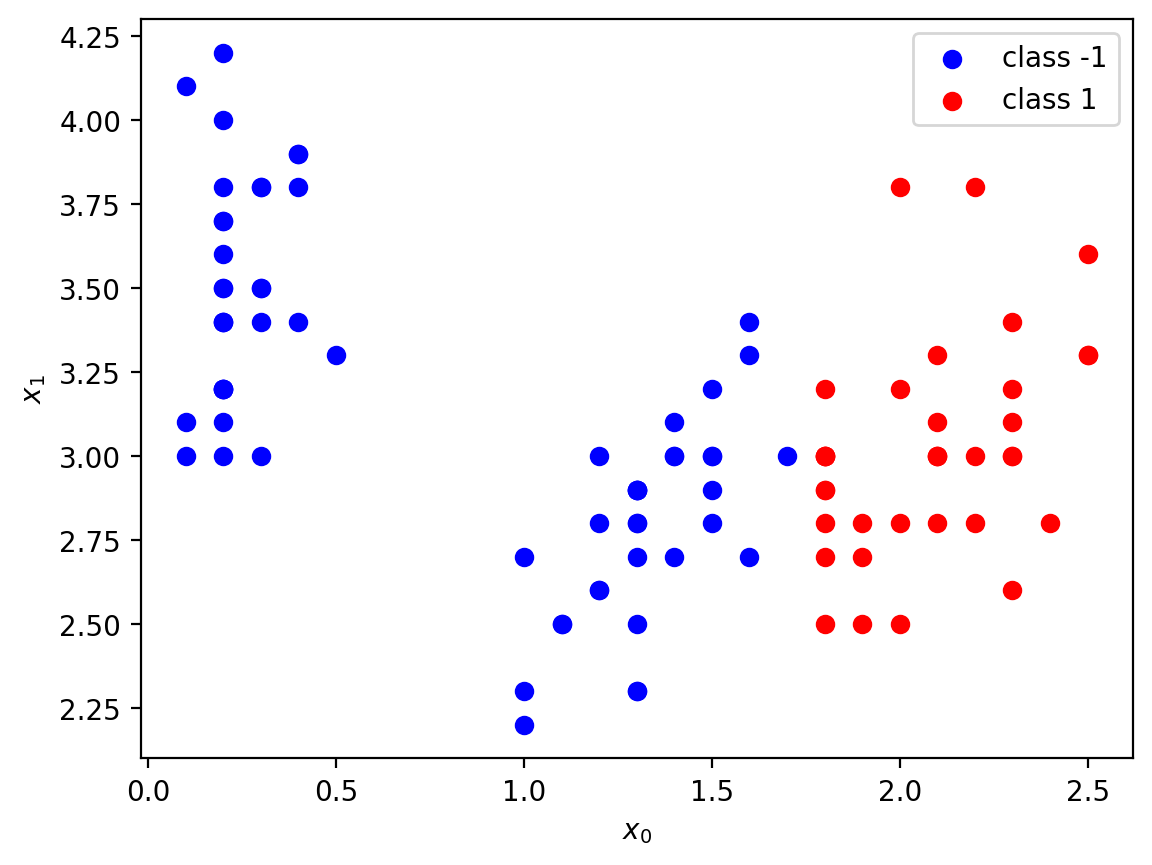

In [6]:
# Visualize training set.
vis(X_train, Y_train)

### Linear SVM Using Gradient Descent

In this problem, we would like to use the gradient descent to calculate the parameters $\mathbf{w},b$ for a linear SVM model.
If we have the loss function $\mathcal{L}(\mathbf{w},b)$, then a typical gradient descent algorithm contains the following steps:

**Step 1**. Initialize the parameters $\mathbf{w}$, $b$.

for i = 1 to #iterations:

- **Step 2**. Compute the partial derivatives $\frac{\partial \mathcal{L}(\mathbf{w},b)}{\partial \mathbf{w}}$, $\frac{\partial \mathcal{L}(\mathbf{w},b)}{\partial b}$.

- **Step 3**. Update the parameters
$$\mathbf{w} \leftarrow \mathbf{w} - \eta \frac{\partial \mathcal{L}(\mathbf{w}, b)}{\partial \mathbf{w}}, \quad\quad b \leftarrow b - \eta \frac{\partial \mathcal{L}(\mathbf{w},b)}{\partial b}$$
where $\eta$ is the learning rate.

Note that in the code, we use `W` and `b` to represent the weight vector $\mathbf{w}$ and bias scalar $b$.In this problem, we would like to use the gradient descent to calculate the parameters $\mathbf{w},b$ for a linear SVM model.
If we have the loss function $\mathcal{L}(\mathbf{w},b)$, then a typical gradient descent algorithm contains the following steps:

**Step 1**. Initialize the parameters $\mathbf{w}$, $b$.

for i = 1 to #iterations:

- **Step 2**. Compute the partial derivatives $\frac{\partial \mathcal{L}(\mathbf{w},b)}{\partial \mathbf{w}}$, $\frac{\partial \mathcal{L}(\mathbf{w},b)}{\partial b}$.

- **Step 3**. Update the parameters
$$\mathbf{w} \leftarrow \mathbf{w} - \eta \frac{\partial \mathcal{L}(\mathbf{w}, b)}{\partial \mathbf{w}}, \quad\quad b \leftarrow b - \eta \frac{\partial \mathcal{L}(\mathbf{w},b)}{\partial b}$$
where $\eta$ is the learning rate.

Note that in the code, we use `W` and `b` to represent the weight vector $\mathbf{w}$ and bias scalar $b$.

_Points:_ 10

In [7]:
# Judge function: 1(a != b). It supports scalar, vector and matrix.
def judge_1(a, b):
    return np.array(a != b).astype(np.float32)

# Judge function: 1(z > 0). It supports scalar, vector and matrix.
def judge_2(z):
    return np.array(z > 0).astype(np.float32)

# Rectifier function: (z)_+ = max(0, z). It supports scalar, vector and matrix.
def rectifier(z):
    return np.clip(z, a_min=0, a_max=None)

# Linear SVM classifier.
def f_linear_svm(x, W, b):
    # x should be a 2-dimensional vector,
    # W should be a 2-dimensional vector,
    # b should be a scalar.
    # you should return a scalar which is -1 or 1.
    dec = np.dot(W, x) + b 
    if dec > 0:
        return 1
    else:
        return -1

# Calculate error given feature vectors X and labels Y.
def calc_error(X, Y, W, b):
    n = len(Y)
    e = 0
    for i in range(n):
        pred = f_linear_svm(X[i], W, b)
        if pred != Y[i]:
            e += 1
    return e / n



In [14]:
# Gradient of L(W, b) with respect to W and b.
def grad_L_W_b(X, Y, W, b, C):
    W = np.array(W, dtype= np.float64)
    X = np.array(X)
    Y = np.array(Y)
    grad_W = W.copy()
    grad_b = 0.0
    n = len(Y)
    for i in range(n):
        xi = X[i]
        ai = 1- Y[i] * (np.dot(W, xi) + b)
        if ai > 0:
            grad_W -= C * Y[i] * xi
            grad_b -= C * Y[i]
    return grad_W, grad_b


In [15]:
grad_L_W_b(X_train, Y_train, [2, 3], 4, 2)

(array([102.4, 398.8]), np.float64(126.0))

In [10]:
# Loss L(W, b).
def L_W_b(X, Y, W, b, C):
    reg = .5 * np.dot(W, W)
    loss = 0 
    n = len(Y)
    for i in range(n): 
        a_i = 1 - Y[i] * (np.dot(W, X[i]) + b)
        loss += max(0, a_i)
    return reg + C * loss

In [11]:
L_W_b(X_train, Y_train, [2, 3], 4, 2)

np.float64(2024.6999999999996)

In [12]:
# Some settings.
learning_rate = 0.0001
iterations    = 10000
losses = []

# Gradient descent algorithm for linear SVM classifier.
# Step 1. Initialize the parameters W, b.
W = np.zeros(2)
b = 0
C = 1000

for i in range(iterations):
    # Step 2. Compute the partial derivatives.
    grad_W, grad_b = grad_L_W_b(X_train, Y_train, W, b, C)
    # Step 3. Update the parameters.
    W = W - learning_rate * grad_W
    b = b - learning_rate * grad_b

    # Track the training losses.
    losses.append(L_W_b(X_train, Y_train, W, b, C))

KeyboardInterrupt: 

In [ ]:
losses

[np.float64(921399.0280500002),
 np.float64(990926.6620263797),
 np.float64(1806899.6274249726),
 np.float64(21101.51444875737),
 np.float64(343447.0089050926),
 np.float64(723244.890305427),
 np.float64(688736.727173084),
 np.float64(993364.7110159211),
 np.float64(387129.1352968911),
 np.float64(533236.969324686),
 np.float64(707575.5679963855),
 np.float64(137789.85897686926),
 np.float64(638604.8382531828),
 np.float64(151146.58102118238),
 np.float64(645810.7417879293),
 np.float64(126065.62615497282),
 np.float64(502186.29328645),
 np.float64(258310.38868669208),
 np.float64(747279.0323231),
 np.float64(42896.778916436044),
 np.float64(144578.59777044485),
 np.float64(583491.2308563566),
 np.float64(525896.5388134726),
 np.float64(162763.834962713),
 np.float64(382289.99296161684),
 np.float64(294803.174868703),
 np.float64(627402.6496178411),
 np.float64(70190.5808919707),
 np.float64(81561.15163028985),
 np.float64(138051.26228464415),
 np.float64(278915.37181335164),
 np.float

In [ ]:
grader.check("Q1_1")

Q1_1 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Visualize the results

Please complete the following codes to visualize the decision boundary of the perceptron model. You may use the `vis` function defined above.

Also, please plot the training error curve with respect to the number of iterations.

You should only insert your code in the `...` part.

_Points:_ 4

Decision boundary: 29.214x0+-2.761x1+-42.700=0


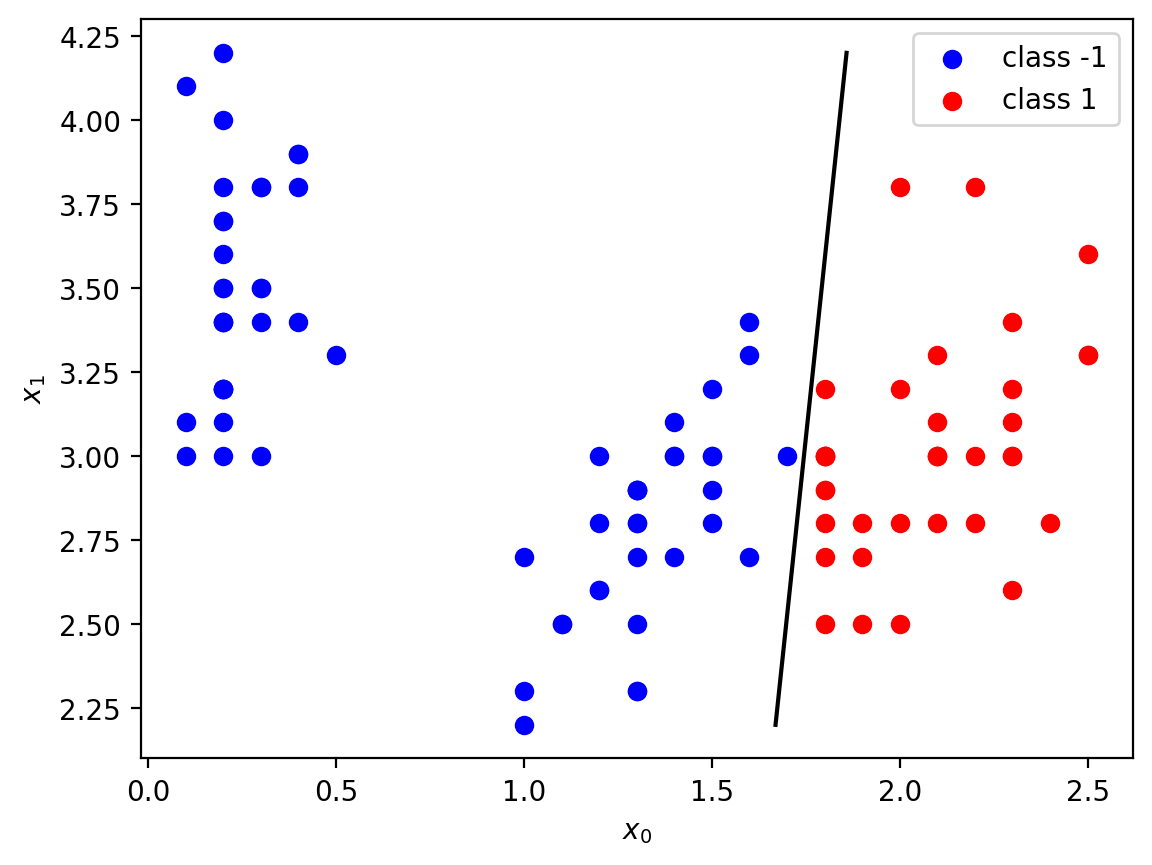

Training error: 0.0


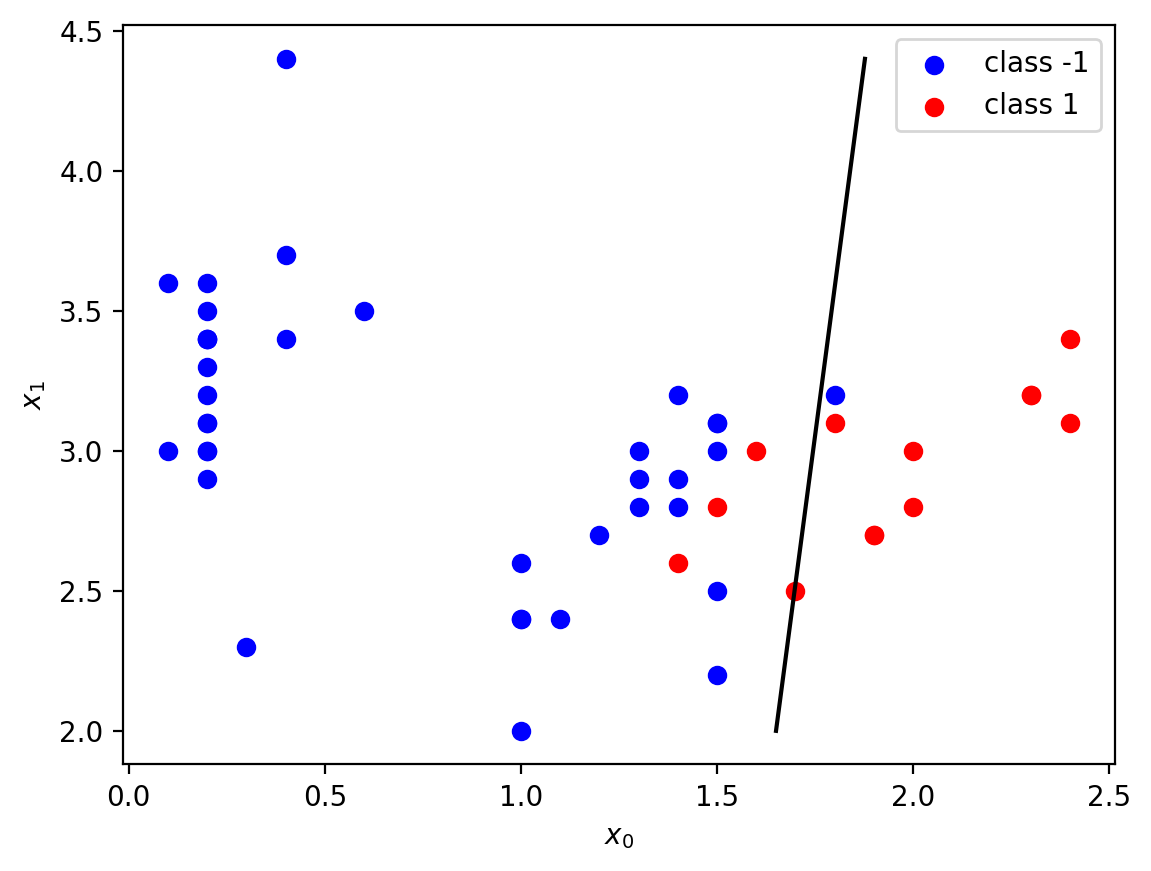

Test error: 0.08


In [ ]:
# Show decision boundary, training error and test error.
print('Decision boundary: {:.3f}x0+{:.3f}x1+{:.3f}=0'.format(W[0],W[1],b))
vis(X_train, Y_train, W, b)
print('Training error: {}'.format(calc_error(X_train, Y_train, W, b)))
vis(X_test, Y_test, W, b)
print('Test error: {}'.format(calc_error(X_test, Y_test, W, b)))

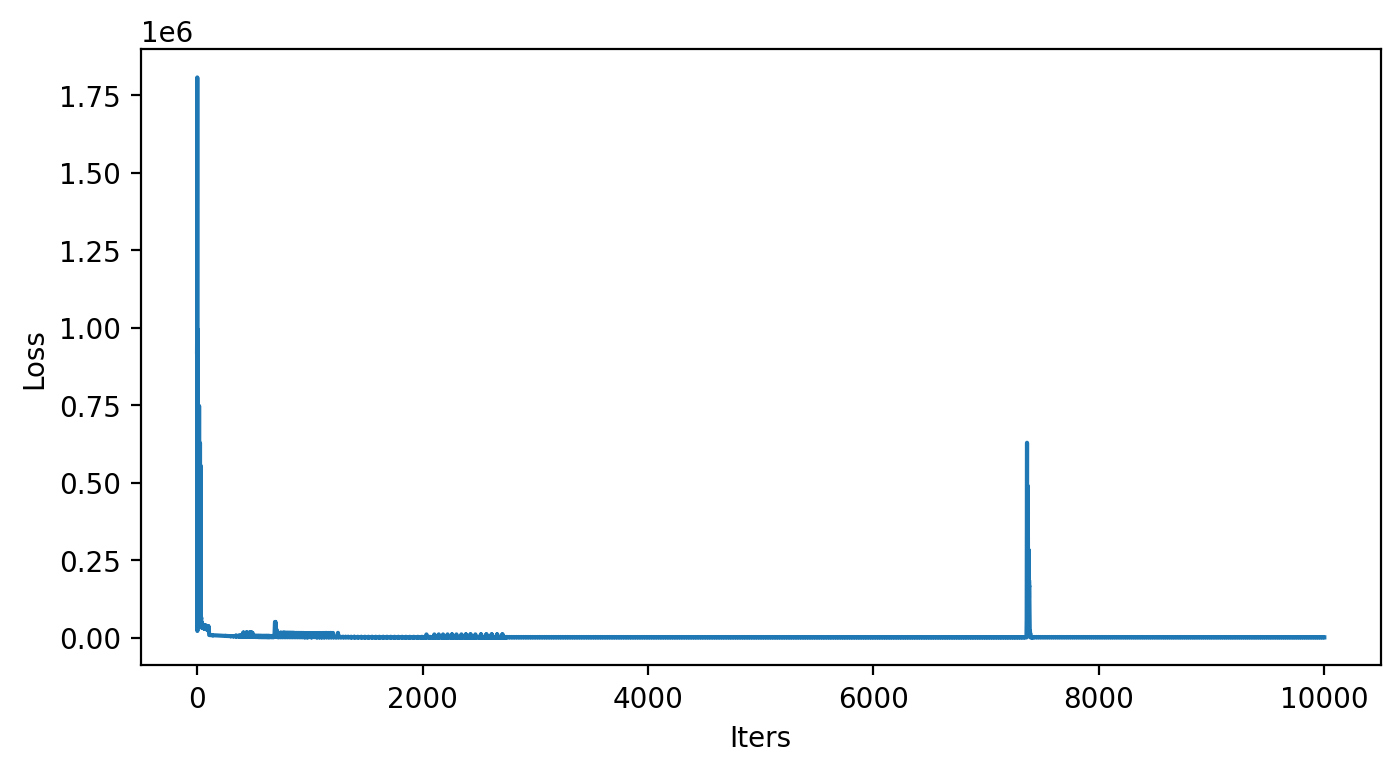

In [ ]:
# Plot training loss curve.
plt.figure( figsize=(8,4))
plt.plot(losses)
plt.xlabel('Iters')
plt.ylabel('Loss')
plt.show()

<!-- END QUESTION -->

# Question 2 SVM with Scikit-Learn

In this problem, you are required to solve the same binary classification problem from Question 1. You are allowed to use the functions from `scikit-learn` in this question.


Load the training set $S_\text{training}$ and the test set $S_\text{test}$: In the code, we use `X_train` and `Y_train` to represent the feature vectors and the labels of the training set $S_\text{training}$ respectively. Similarly, we use `X_test` and `Y_test` for the test set $S_\text{test}$.

Train the SVM classifier using a linear kernel: In the SVM, there is a hyper-parameter $C$. We train the linear SVM classifier on the training set $S_\text{training}$ with each $C$ from the list below and calculate its training error $e_\text{training}$:
$$C \in \{0.1, 1, 10, 100, 1000\}$$

We aim to obtain the best hyper-parameter $C^*$ corresponding to the minimum **training error** $e_\text{training}^*$ among all $C$s listed above.

Use the trained classifier corresponding to the best hyper-parameter $C^*$ to calculate the test error $e_\text{test}$ on test set $S_\text{test}$.   




In [ ]:
%config InlineBackend.figure_format = 'retina'
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn import svm
from sklearn.metrics import accuracy_score

### Load the modified Iris dataset

In [ ]:
# Iris dataset.
iris = datasets.load_iris()     # Load Iris dataset.

X = iris.data                   # The shape of X is (150, 4), which means
                                # there are 150 data points, each data point
                                # has 4 features.

# Here for convenience, we divide the 3 kinds of flowers into 2 groups:
#     Y = 0 (or False):  Setosa (original value 0) / Versicolor (original value 1)
#     Y = 1 (or True):   Virginica (original value 2)

# Thus we use (iris.target > 1.5) to divide the targets into 2 groups.
# This line of code will assign:
#    Y[i] = True  (which is equivalent to 1) if iris.target[k]  > 1.5 (Virginica)
#    Y[i] = False (which is equivalent to 0) if iris.target[k] <= 1.5 (Setosa / Versicolor)

Y = (iris.target > 1.5).reshape(-1,1).astype(float) # The shape of Y is (150, 1), which means
                                # there are 150 data points, each data point
                                # has 1 target value.
Y[Y==0] = -1

X_and_Y = np.hstack((X, Y))     # Stack them together for shuffling.
np.random.seed(1)               # Set the random seed.
np.random.shuffle(X_and_Y)      # Shuffle the data points in X_and_Y array

print(X.shape)
print(Y.shape)
print(X_and_Y[0])               # The result should be always: [ 5.8  4.   1.2  0.2  -1. ]

(150, 4)
(150, 1)
[ 5.8  4.   1.2  0.2 -1. ]


In [ ]:
# Divide the data points into training set and test set.
X_shuffled = X_and_Y[:,:4]
Y_shuffled = X_and_Y[:,4]


X_train = X_shuffled[:100][:,[3,1]] # Shape: (100,2)
X_train = np.delete(X_train, 42, axis=0) # Remove a point for separability.
Y_train = Y_shuffled[:100]          # Shape: (100,)
Y_train = np.delete(Y_train, 42, axis=0) # Remove a point for separability.
X_test = X_shuffled[100:][:,[3,1]]  # Shape: (50,2)
Y_test = Y_shuffled[100:]           # Shape: (50,)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(99, 2)
(99,)
(50, 2)
(50,)


### Visualization

In [ ]:
def vis(X, Y, W=None, b=None):
    indices_neg1 = (Y == -1).nonzero()[0]
    indices_pos1 = (Y == 1).nonzero()[0]
    plt.scatter(X[:,0][indices_neg1], X[:,1][indices_neg1],
                c='blue', label='class -1')
    plt.scatter(X[:,0][indices_pos1], X[:,1][indices_pos1],
                c='red', label='class 1')
    plt.legend()
    plt.xlabel('$x_0$')
    plt.ylabel('$x_1$')

    if W is not None:
        # w0x0+w1x1+b=0 => x1=-w0x0/w1-b/w1
        w0 = W[0]
        w1 = W[1]
        temp = -w1*np.array([X[:,1].min(), X[:,1].max()])/w0-b/w0
        x0_min = max(temp.min(), X[:,0].min())
        x0_max = min(temp.max(), X[:,1].max())
        x0 = np.linspace(x0_min,x0_max,100)
        x1 = -w0*x0/w1-b/w1
        plt.plot(x0,x1,color='black')

    plt.show()

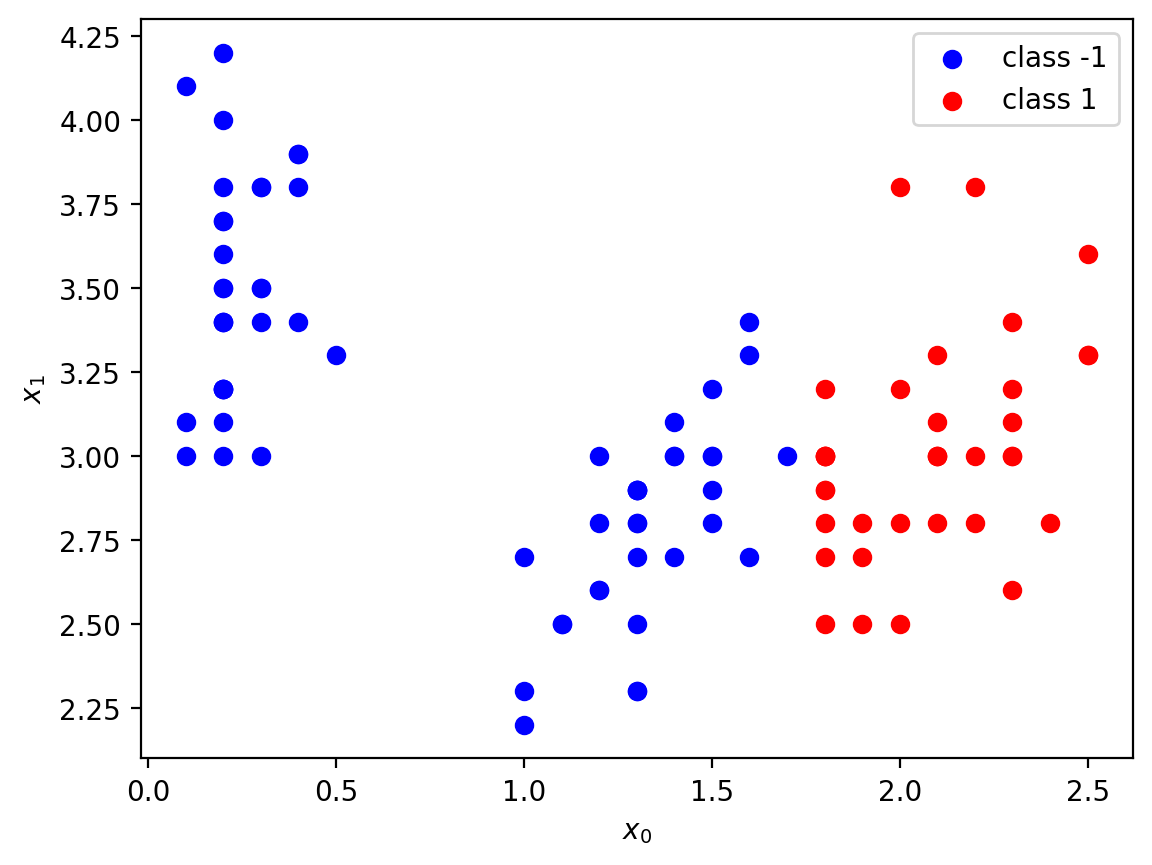

In [ ]:
# Visualize training set.
vis(X_train, Y_train)

<!-- BEGIN QUESTION -->

### Linear SVM Using Scikit-Learn

_Points:_ 4

In [ ]:
# Calculate error given feature vectors X and labels Y.
def calc_error(X, Y, classifier):

    # Hint: Use classifier.predict()
    Y_pred = classifier.predict(X)

    # Hint: Use accuracy_score().
    e = 1 - accuracy_score(Y, Y_pred)
    return e

C = 0.1
Decision boundary: 1.307x0+-0.520x1+-0.397=0


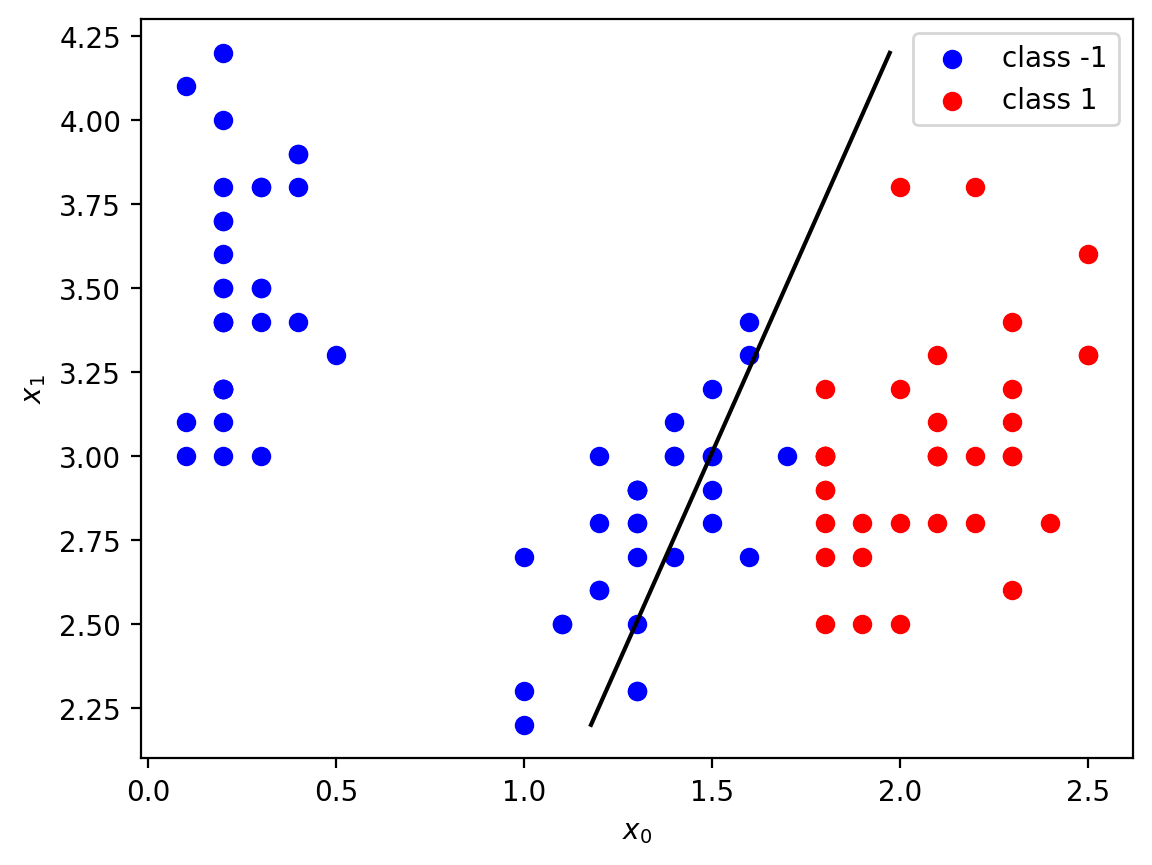

Training error: 0.101010101010101




C = 1
Decision boundary: 3.446x0+-1.386x1+-1.665=0


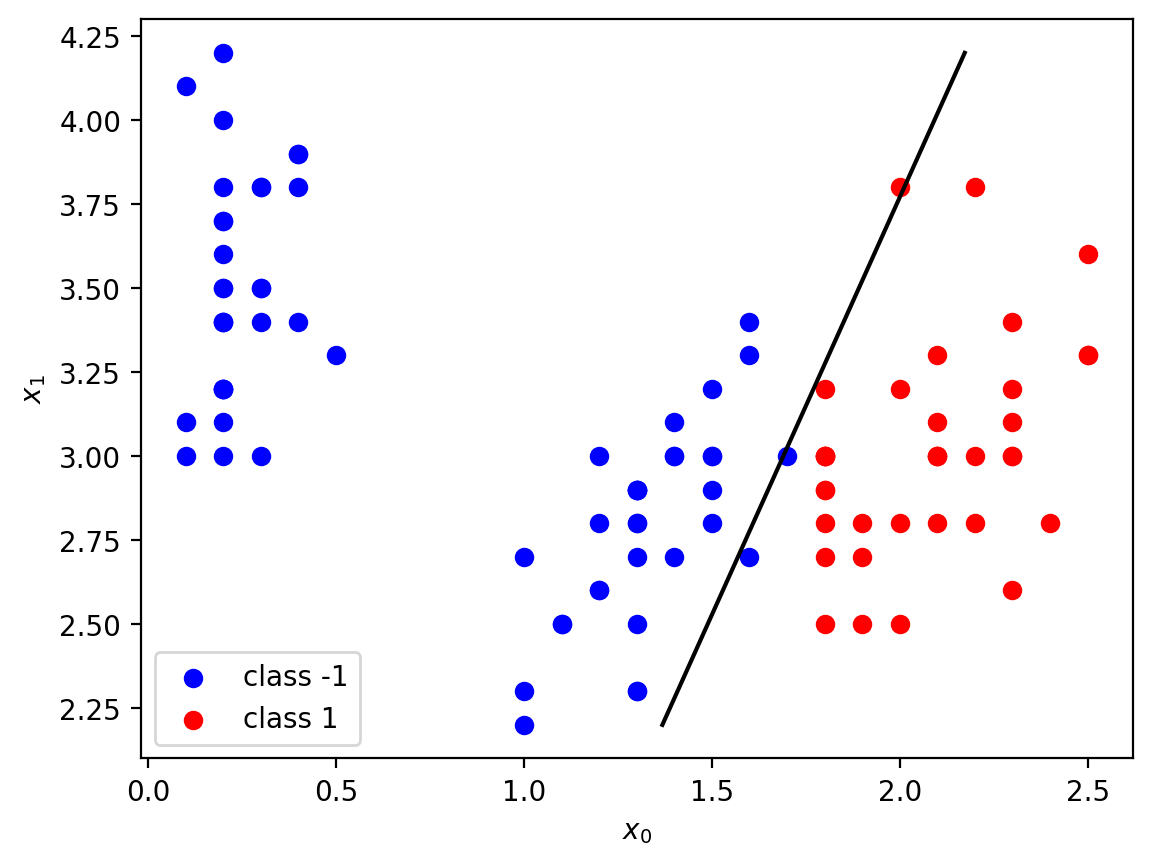

Training error: 0.030303030303030276




C = 10
Decision boundary: 6.666x0+-1.905x1+-5.286=0


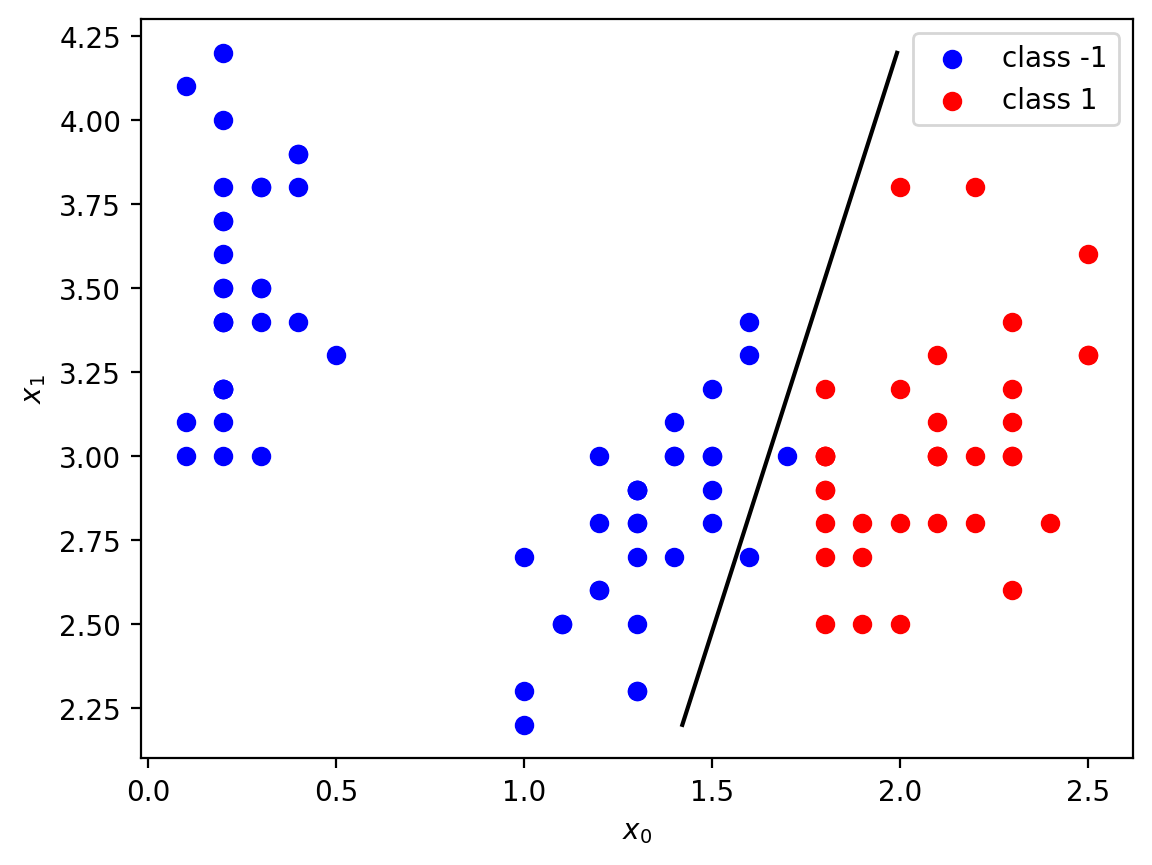

Training error: 0.02020202020202022




C = 100
Decision boundary: 9.290x0+-0.473x1+-14.305=0


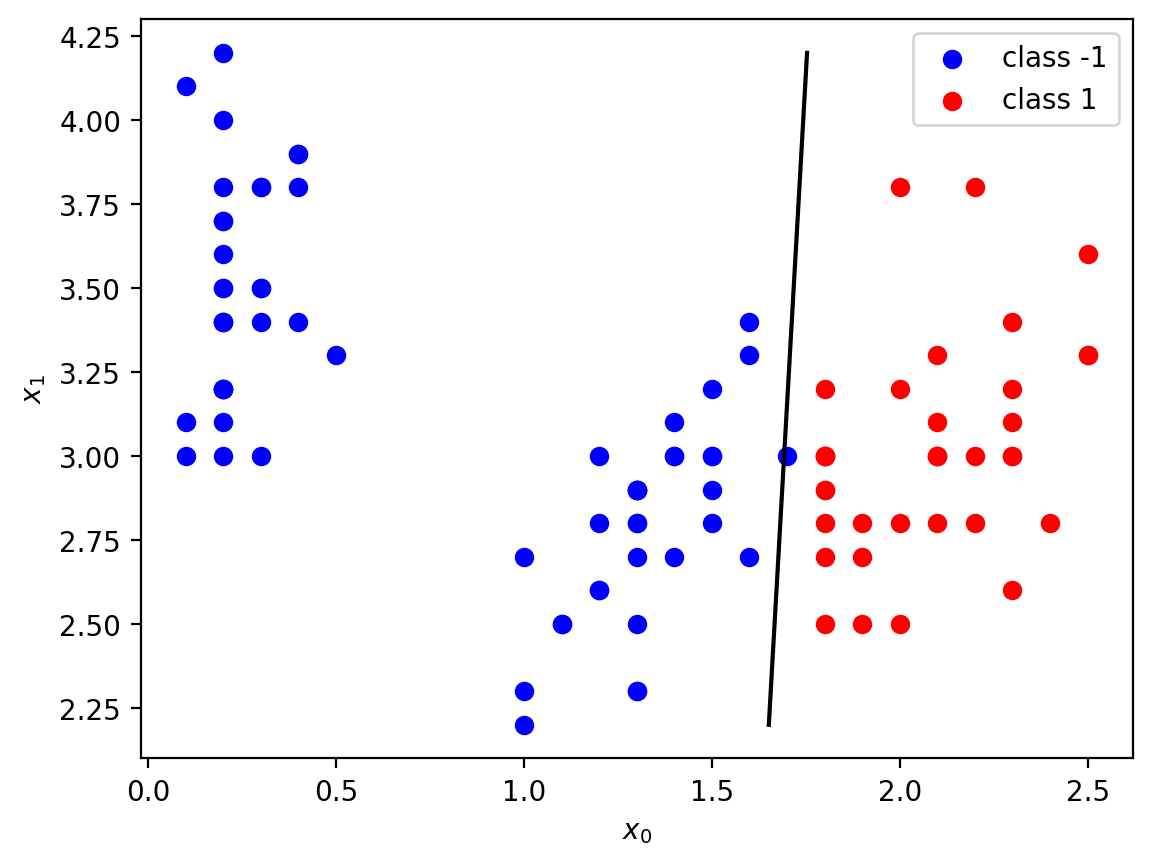

Training error: 0.010101010101010055




C = 1000
Decision boundary: 19.999x0+-0.000x1+-34.998=0


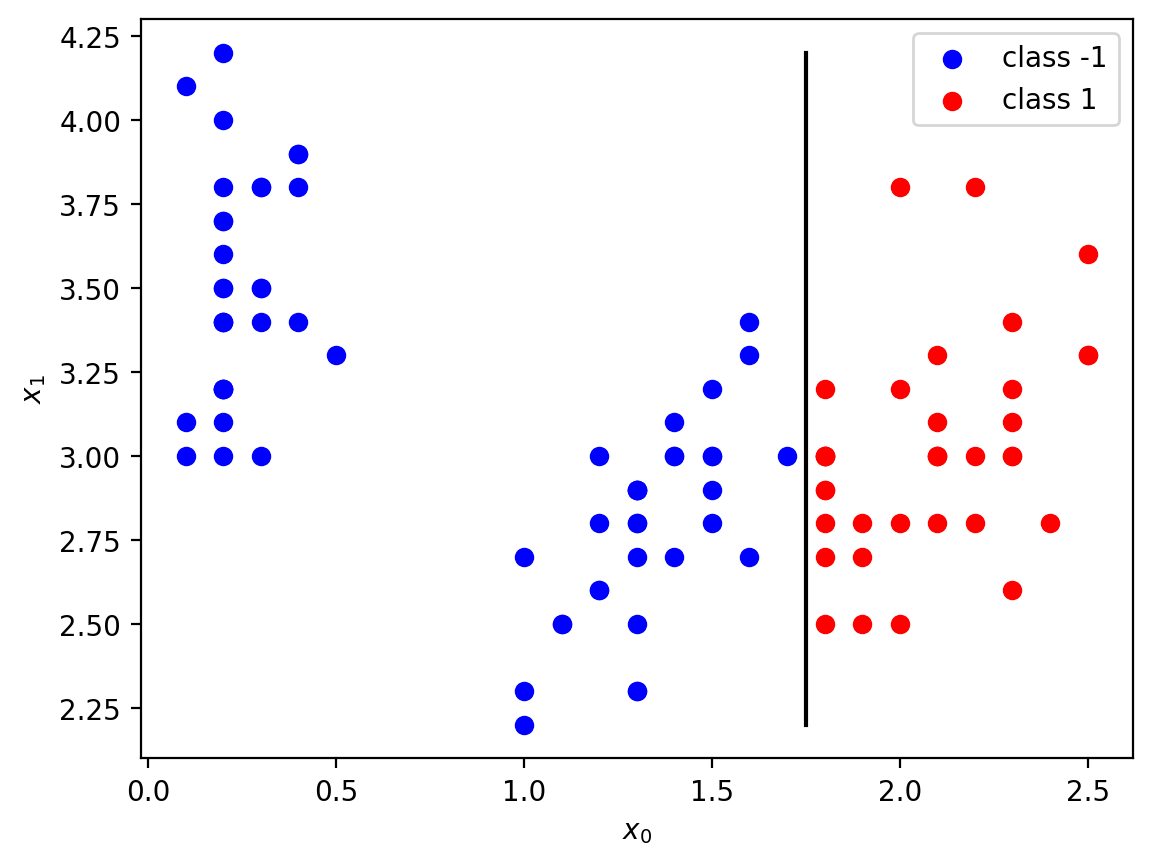

Training error: 0.0






In [ ]:
C_list = [0.1, 1, 10, 100, 1000]
opt_e_training = 1.0   # Optimal training error.
opt_classifier = None  # Optimal classifier.
opt_C          = None  # Optimal C.

for C in C_list:
    # Create a linear SVM classifier.
    # Hints: You can use svm.LinearSVC()
    #        Besides, we use Hinge loss and L2 penalty for weights.
    #        The max iterations should be set to 100000.
    #        The regularization parameter should be set as C.
    #        The other arguments of svm.LinearSVC() are set as default values.
    classifier = svm.LinearSVC(loss='hinge', penalty='l2', C=C, max_iter=100000)   

    # Use the classifier to fit the training set (use X_train, Y_train).
    # Hint: You can use classifier.fit().

    classifier.fit(X_train, Y_train)

    

    # Obtain the weights and bias from the linear SVM classifier.
    W = classifier.coef_[0]
    b = classifier.intercept_[0]

    # Show decision boundary, training error and test error.
    print('C = {}'.format(C))
    print('Decision boundary: {:.3f}x0+{:.3f}x1+{:.3f}=0'.format(W[0],W[1],b))
    vis(X_train, Y_train, W, b)
    e_training = calc_error(X_train, Y_train, classifier)
    print('Training error: {}'.format(e_training))
    print('\n\n\n')

    # Judge if it is the optimal one.
    if e_training < opt_e_training:
        opt_e_training = e_training
        opt_classifier = classifier
        opt_C = C

Best parameter C* = 1000
Decision boundary: 19.999x0+-0.000x1+-34.998=0


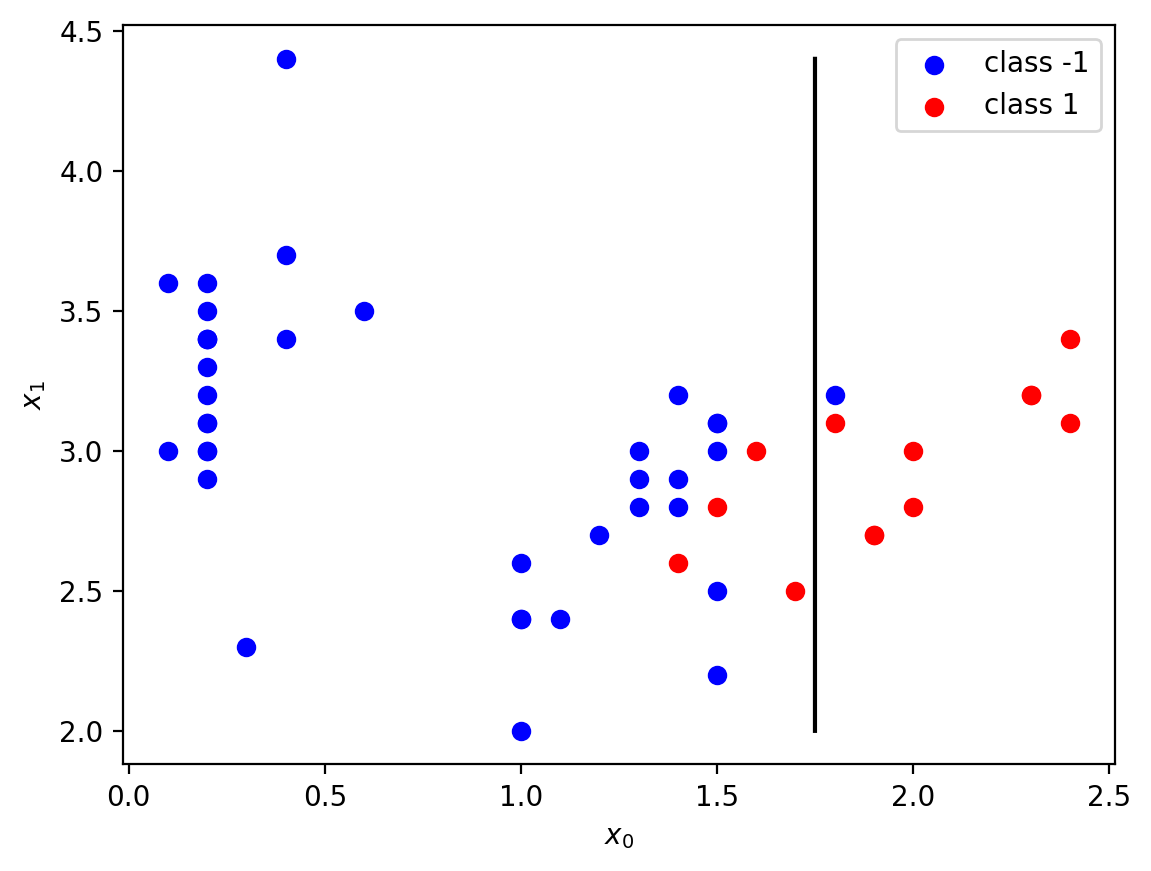

Test error: 0.09999999999999998


In [ ]:
# Obtain the weights and bias from the best linear SVM classifier.
opt_W = opt_classifier.coef_[0]
opt_b = opt_classifier.intercept_[0]
print('Best parameter C* = {}'.format(opt_C))
print('Decision boundary: {:.3f}x0+{:.3f}x1+{:.3f}=0'.format(opt_W[0],opt_W[1],opt_b))
vis(X_test, Y_test, opt_W, opt_b)
print('Test error: {}'.format(calc_error(X_test, Y_test, opt_classifier)))

<!-- END QUESTION -->

# Question 3 Cross Validation

Given a training dataset $S_\text{training} = \{(x_i, y_i)\}, i=1,\ldots,6\}$ where $x_i \in \mathbb{R}$ is the feature scalar and $y_i \in \{-1, +1\}$ is the corresponding label. The data points in the dataset $S_\text{training}$ are given below:
$$(x_1, y_1) = (2, -1), \quad (x_2, y_2) = (7, -1), \quad (x_3, y_3) = (4, +1),$$
$$(x_4, y_4) = (1, -1), \quad (x_5, y_5) = (3, +1), \quad (x_6, y_6) = (6, +1).$$

Suppose you are training a linear classifier $f(x;a,b) = \text{sign}(ax + b)$ with 2-fold cross-validation where $\text{sign}(z)$ is defined as:
$$
\text{sign}(z) = \left\{
             \begin{array}{cl}
              1,  & z \geq 0 \\
             -1,  & z < 0.
             \end{array}  
        \right. \nonumber
$$

- You have split the dataset $S_\text{training}$ into:
$$S_1 = \{(x_1, y_1), (x_2, y_2), (x_3, y_3)\}$$
$$S_2 = \{(x_4, y_4), (x_5, y_5), (x_6, y_6)\}$$

- After training the classifier $f(x;a,b)$ on $S_1$, you have obtained the parameters $a_1 = -1, b_1 = 5$ and then try to validate the classifier on $S_2$.

- After training the classifier $f(x;a,b)$ on $S_2$, you have obtained the parameters $a_2 = 2, b_2 = -3$ and then try to validate the classifier on $S_1$.


Please finish the tasks below:

1. Calculate the **average training error** in the 2-fold cross-validation.
    
    **Note:** The definition of average training error is the mean of the error of classifier $f(x; a_1, b_1)$ on $S_1$ and the error of classifier $f(x; a_2, b_2)$ on $S_2$.
    
2. Calculate the **average validation error** (i.e. the cross-validation error) in the 2-fold cross-validation.





_Points:_ 6

In [ ]:
a1, b1, a2, b2 = -1, 5, 2, -3
S1x = np.array([2, 7, 4])
S1y = np.array([-1, -1, 1])
S2x = np.array([1, 3, 6])
S2y = np.array([-1, 1, 1])

err1 = sum(1 if (a1*x + b1 >= 0) != (y == 1)
           else 0 
           for x, y in zip(S1x, S1y))
err1 = err1 / len(S1x)

err2 = sum(1 if (a2*x + b2 >= 0) != (y == 1)
           else 0 
           for x, y in zip(S2x, S2y))
err2 = err2 / len(S2x)

AVG_TRAINING_ERROR = (err1 + err2) / 2

err1_2 = sum(1 if (a1*x + b1 >= 0) != (y == 1)
           else 0 
           for x, y in zip(S2x, S2y))
err1_2 = err1_2 / len(S2x)
err2_1 = sum(1 if (a2*x + b2 >= 0) != (y == 1)
           else 0 
           for x, y in zip(S1x, S1y))
err2_1 = err2_1 / len(S1x)
AVG_VAL_ERROR = (err1_2 + err2_1)/ 2

#print (AVG_TRAINING_ERROR, AVG_VAL_ERROR)

<!-- BEGIN QUESTION -->

# Question 4 SVM with the RBF Kernel (Bonus)

In this problem, you are required to solve the same binary classification problem from Question 3 using `scikit-learn`. However, you need to use the SVM with the radial basis function (RBF) kernel to conduct the binary classification in this question.

- Load the training set $S_\text{training}$ and the test set $S_\text{test}$: In the code, we use `X_train` and `Y_train` to represent the feature vectors and the labels of the training set $S_\text{training}$ respectively. Similarly, we use `X_test` and `Y_test` for the test set $S_\text{test}$.

- Train the SVM classifier using a RBF kernel: For the SVM with the RBF kernel, there are two hyper-parameters, $C$ and $\gamma$, to control the model. We train the SVM classifier on the training set $S_\text{training}$ with each combination of $C$ and $\gamma$ from the list below and calculate its training error $e_\text{training}$:
$$C \in \{1, 10, 100, 1000, 10000\}, \quad\quad \gamma \in \{10^{-6}, 10^{-5}, 10^{-4}, 10^{-3}, 10^{-2}\}$$

We aim to obtain the best hyper-parameters $(C^*, \gamma^*)$ corresponding to the minimum \textbf{training error} $e_\text{training}^*$ among all combinations of $C\text{s}$ and $\gamma\text{s}$ listed above.

- Use the trained classifier corresponding to the best hyper-parameters $(C^*, \gamma^*)$ to calculate the test error $e_\text{test}$ on test set $S_\text{test}$.   

Please write the code and provide a heatmap of training errors corresponding to all combinations of $(C, \gamma)$.




In [ ]:
%config InlineBackend.figure_format = 'retina'
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn import svm
from sklearn.metrics import accuracy_score
import seaborn as sns

### Load the modified Iris dataset

In [ ]:
# Iris dataset.
iris = datasets.load_iris()     # Load Iris dataset.

X = iris.data                   # The shape of X is (150, 4), which means
                                # there are 150 data points, each data point
                                # has 4 features.

# Here for convenience, we divide the 3 kinds of flowers into 2 groups:
#     Y = 0 (or False):  Setosa (original value 0) / Versicolor (original value 1)
#     Y = 1 (or True):   Virginica (original value 2)

# Thus we use (iris.target > 1.5) to divide the targets into 2 groups.
# This line of code will assign:
#    Y[i] = True  (which is equivalent to 1) if iris.target[k]  > 1.5 (Virginica)
#    Y[i] = False (which is equivalent to 0) if iris.target[k] <= 1.5 (Setosa / Versicolor)

Y = (iris.target > 1.5).reshape(-1,1).astype(float) # The shape of Y is (150, 1), which means
                                # there are 150 data points, each data point
                                # has 1 target value.
Y[Y==0] = -1

X_and_Y = np.hstack((X, Y))     # Stack them together for shuffling.
np.random.seed(1)               # Set the random seed.
np.random.shuffle(X_and_Y)      # Shuffle the data points in X_and_Y array

print(X.shape)
print(Y.shape)
print(X_and_Y[0])               # The result should be always: [ 5.8  4.   1.2  0.2  -1. ]

(150, 4)
(150, 1)
[ 5.8  4.   1.2  0.2 -1. ]


In [ ]:
# Divide the data points into training set and test set.
X_shuffled = X_and_Y[:,:4]
Y_shuffled = X_and_Y[:,4]


X_train = X_shuffled[:100][:,[3,1]] # Shape: (100,2)
X_train = np.delete(X_train, 42, axis=0) # Remove a point for separability.
Y_train = Y_shuffled[:100]          # Shape: (100,)
Y_train = np.delete(Y_train, 42, axis=0) # Remove a point for separability.
X_test = X_shuffled[100:][:,[3,1]]  # Shape: (50,2)
Y_test = Y_shuffled[100:]           # Shape: (50,)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(99, 2)
(99,)
(50, 2)
(50,)


### SVM with RBF Using Scikit-Learn

_Points:_ 8

In [ ]:
# Calculate error given feature vectors X and labels Y.
def calc_error(X, Y, classifier):
    Y_pred = classifier.predict(X)
    e = 1 - accuracy_score(Y, Y_pred)
    return e


# Draw the heatmap of training errors.
def draw_heatmap(training_errors, gamma_list, C_list):
    # training_errors: A NumPy array with the shape (len(C_list), len(gamma_list))
    # gamma_list: List of gamma(s).
    # C_list: List of C(s).
    plt.figure(figsize = (5,4))
    ax = sns.heatmap(training_errors, annot=True, fmt='.3f',
                     xticklabels=gamma_list, yticklabels=C_list)
    ax.collections[0].colorbar.set_label("error")
    ax.set(xlabel = r'$\gamma$', ylabel=r'$C$')
    plt.title(r'Training error w.r.t $C$ and $\gamma$')
    plt.show()

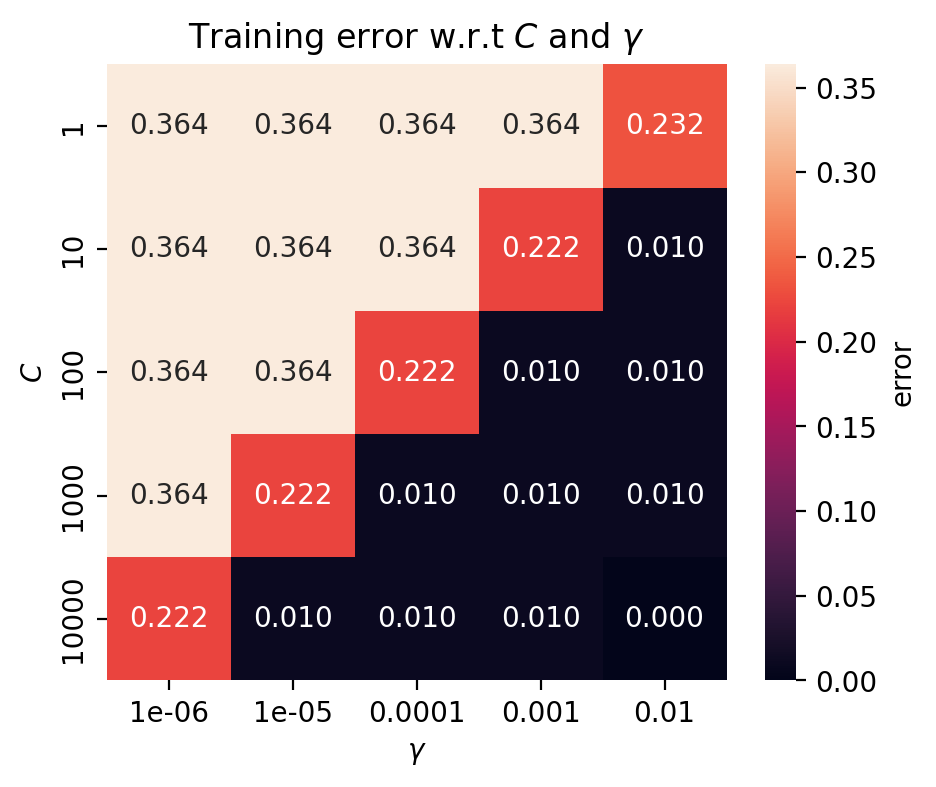

In [ ]:
C_list = [1, 10, 100, 1000, 10000]
gamma_list = [1e-6, 1e-5, 1e-4, 1e-3,1e-2]

# An example of using draw_heatmap().
#    errors = np.random.random((len(C_list), len(gamma_list)))
#    draw_heatmap(errors, gamma_list, C_list)
#  ......  Hint: You may use svm.SVC().

errors = np.random.random((len(C_list), len(gamma_list)))
opt_e_training = 1.0  
opt_classifier = None
opt_C = None
opt_gamma = None

for i, C in enumerate(C_list):
    for j, gamma in enumerate(gamma_list):
        classifier = svm.SVC(C=C, kernel='rbf', gamma=gamma)
        classifier.fit(X_train, Y_train)
        e_training = calc_error(X_train, Y_train, classifier)
        errors[i][j] = e_training
        if e_training < opt_e_training:
            opt_e_training = e_training
            opt_classifier = classifier
            opt_C = C
            opt_gamma = gamma


draw_heatmap(errors, gamma_list, C_list)


<!-- END QUESTION -->

# Question 5 K Nearest Neighbors (Bonus)

In this problem, you need to implement the $k$ nearest neighbors ($k$-NN) algorithm and apply it to the binary classification. Here we use the modified Iris dataset $S=\{(\mathbf{x}_i, y_i)\}$ where each feature vector $\mathbf{x} \in \mathbb{R}^2$ and label $y \in \{-1, +1\}$. You are **not** allowed to use `sklearn.neighbors.KNeighborsClassifier()` in your code, but you can use it to validate your implementation.


- Load the modified Iris dataset. The dataset $S$ is split to three subsets: The training set $S_\text{training}$, the validation set $S_\text{validation}$ and the test set $S_\text{test}$. In the code, we use `X_train`, `Y_train` for the feature vectors and labels of the training set respectively. Similar notations are also used for the validation and the test sets.

- Implement $k$-NN algorithm in 3 steps.

    1. For each feature vector $\mathbf{x}$ you are predicting a label, you need to calculate the distances between this feature vector $\mathbf{x}$ and all the feature vectors in the training set $S_\text{training}$.
    
    2. Then sort all distances in ascending order and pick the labels for the $k$ minimum distances.
    
    3. Count the number of negative labels $N_{y=-1}$, and the number of the positive labels $N_{y=+1}$ from $k$ labels picked in step 2. Use the following decision rule to predict label $\hat{y}$ for each feature vector $\mathbf{x}$:
    
    $$
        \hat{y} = \left\{
                     \begin{array}{cl}
                      +1,  & N_{y=-1} < N_{y=+1}, \\
                     -1,  & N_{y=-1} \geq N_{y=+1}.
                     \end{array}  
                \right. \nonumber
    $$


Here we assume **Euclidean distance** as the distance metric. For more details, please refer to the code and the corresponding part in the slides.

- Use the validation set to obtain optimal $k^*$. In $k$-NN, there is a hyper-parameter $k$ which adjusts the number of nearest neighbors. You would need to perform a grid search on the following list of $k$:
$$k \in \{1,2,3\}$$

For each $k$, you need to form a $k$-NN classifier with the training set $S_\text{training}$. Then, use the classifier to make predictions on the validation set $S_\text{validation}$ and calculate the error $e_\text{validation}$. We aim to obtain the best hyper-parameter $k^*$ corresponding to the **minimum validation error** $e_\text{validation}^*$ among all $k\text{s}$.

- Use the obtained classifier corresponding to the best hyper-parameter $k^*$ to calculate the test error $e_\text{test}$ on test set $S_\text{test}$.   





In [ ]:
%config InlineBackend.figure_format = 'retina'
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
import scipy
from matplotlib.colors import ListedColormap
from functools import partial

### Load the modified Iris dataset

In [ ]:
# Iris dataset.
iris = datasets.load_iris()     # Load Iris dataset.

X = iris.data                   # The shape of X is (150, 4), which means
                                # there are 150 data points, each data point
                                # has 4 features.

Y = (iris.target > 1.5).reshape(-1,1).astype(float) # The shape of Y is (150, 1), which means
                                # there are 150 data points, each data point
                                # has 1 target value.
Y[Y==0] = -1                    # Convert labels from {0, 1} to {-1, 1}

X_and_Y = np.hstack((X, Y))     # Stack them together for shuffling.
np.random.seed(1)               # Set the random seed.
np.random.shuffle(X_and_Y)      # Shuffle the data points in X_and_Y array

print(X.shape)
print(Y.shape)
print(X_and_Y[0])               # Should be: [5.8 4.  1.2 0.2 -1. ].

(150, 4)
(150, 1)
[ 5.8  4.   1.2  0.2 -1. ]


In [ ]:
# Divide the data points into training set and test set.
X_shuffled = X_and_Y[:,:4]
Y_shuffled = X_and_Y[:,4]

X_train = X_shuffled[:50][:, [3,1]]     # Shape: (50,2)
Y_train = Y_shuffled[:50]               # Shape: (50,)
X_val   = X_shuffled[50:100][:, [3,1]]  # Shape: (50,2)
Y_val   = Y_shuffled[50:100]            # Shape: (50,)
X_test  = X_shuffled[100:][:, [3,1]]    # Shape: (50,2)
Y_test  = Y_shuffled[100:]              # Shape: (50,)
print(X_train.shape)
print(Y_train.shape)
print(X_val.shape)
print(Y_val.shape)
print(X_test.shape)
print(Y_test.shape)

(50, 2)
(50,)
(50, 2)
(50,)
(50, 2)
(50,)


### Visualization

In [ ]:
def vis(X, Y, knn_classifier=None):
    # Visualize k-NN.
    if knn_classifier is not None:
        # Calculate min, max and create grids.
        h = .02
        x0_min, x0_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
        x1_min, x1_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
        x0s, x1s = np.meshgrid(np.arange(x0_min, x0_max, h),
                               np.arange(x1_min, x1_max, h))
        xs = np.stack([x0s, x1s], axis=-1).reshape(-1, 2)

        # Predict class using kNN classifier and data.
        ys_pred = np.array([knn_classifier(x) for x in xs])
        ys_pred = ys_pred.reshape(x0s.shape)

        # Put the result into a color plot.
        # Color map: #00AAFF - blue, #FFAAAA - red, #AAFFAA - green

        cmap_light = ListedColormap(['#00AAFF', '#FFAAAA'])
        plt.pcolormesh(x0s, x1s, ys_pred, cmap=cmap_light, alpha=0.3)

    indices_neg1 = (Y == -1).nonzero()[0]
    indices_pos1 = (Y == 1).nonzero()[0]
    plt.scatter(X[:,0][indices_neg1], X[:,1][indices_neg1],
                c='blue', label='class -1', alpha=0.3)
    plt.scatter(X[:,0][indices_pos1], X[:,1][indices_pos1],
                c='red', label='class +1', alpha=0.3)
    plt.legend()
    plt.xlabel('$x_0$')
    plt.ylabel('$x_1$')

    plt.show()

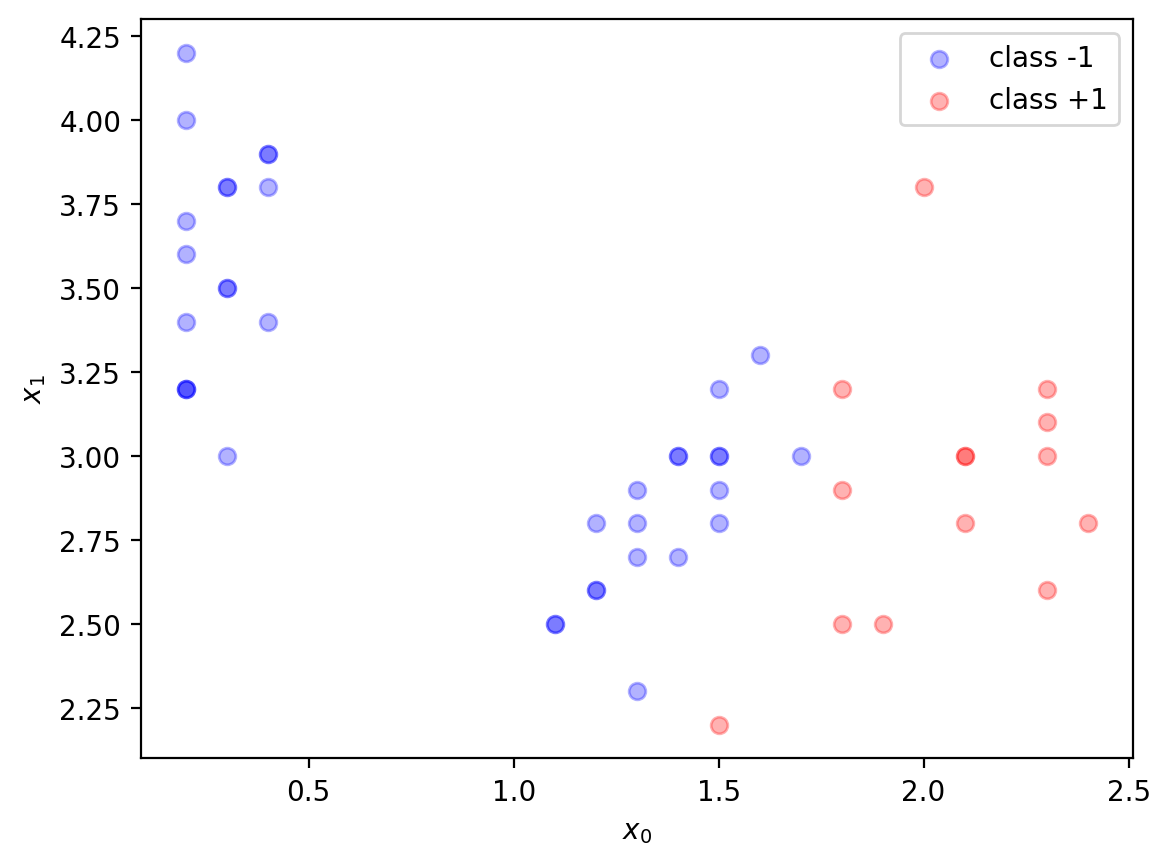

In [ ]:
# Visualize training set.
vis(X_train, Y_train)
# Note that some points have darker color since there can be
# multiple points at the same location.

### k Nearest Neighbors

_Points:_ 8

In [ ]:
# Euclidean distance.
def calc_distance(x1, x2):
    # x1, x2 are two NumPy vectors
    # Return the Euclidean distance between x1 and x2. It should be a scalar.
    dist = np.linalg.norm(x1 - x2)
    return dist

# k nearest neighbor predictor.
def f_knn(x, X_train, Y_train, k):
    # Create the list of (distance, label) pairs.
    dist_label_pairs = []
    for xi, yi in zip(X_train, Y_train):
        # Calculate the distance.
        dist = calc_distance(xi, x)
        # Add a (distance, label) pair to the list.
        dist_label_pairs.append((dist, yi))
    # Sort the pairs by distance (ascending).
    sorted_dist_label_pairs = sorted(dist_label_pairs, key=lambda x:x[0])
    # Obtain the first k pairs (corresponding to k smallest distances).
    k_dist_label_pairs = sorted_dist_label_pairs[:k]
    # Extract the labels of the k pairs.
    k_labels = [pair[1] for pair in k_dist_label_pairs]
    # Count the number of +1 predictions and -1 predictions.
    pos1_in_k_labels = 0
    neg1_in_k_labels = 0
    for label in k_labels:
        if label == +1:
            pos1_in_k_labels += 1
        elif label == -1:
            neg1_in_k_labels += 1
    # Make the prediction based on counts.
    if pos1_in_k_labels > neg1_in_k_labels:
        y_pred = +1
    else:
        y_pred = -1

    return y_pred

# Judge function: 1(a != b). It supports scalar, vector and matrix.
def judge(a, b):
    return np.array(a != b).astype(np.float32)

# Calculate error given feature vectors X and labels Y.
def calc_error(X, Y, knn_classifier):
    e = 0
    n = len(X)
    for (xi, yi) in zip(X, Y):
        e += judge(yi, knn_classifier(xi))
    e = 1.0 * e / n
    return e

<!-- BEGIN QUESTION -->

### Visualize the results

Please complete the following codes to visualize the decision boundary of the perceptron model. You may use the `vis` function defined above.
.

You should only insert your code in the `...` part.

_Points:_ 4

k=1


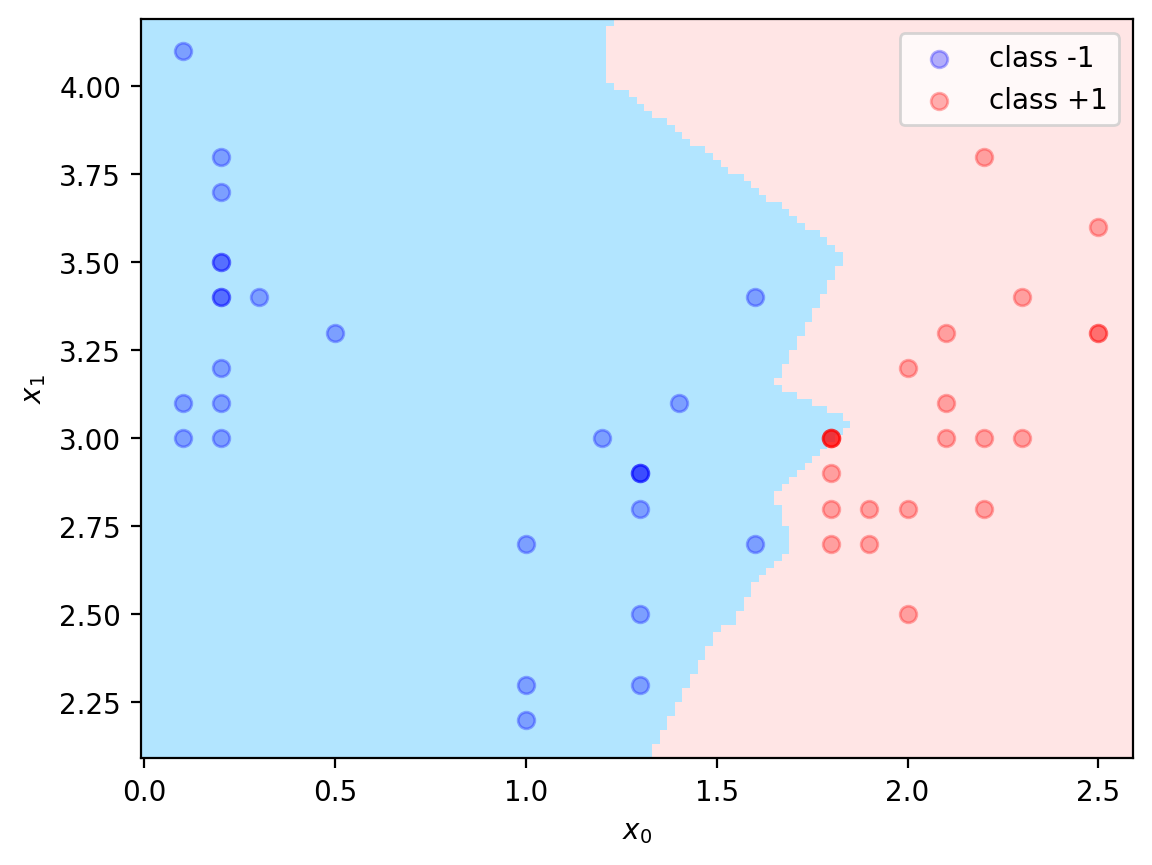

Validation error: 0.07999999821186066

k=2


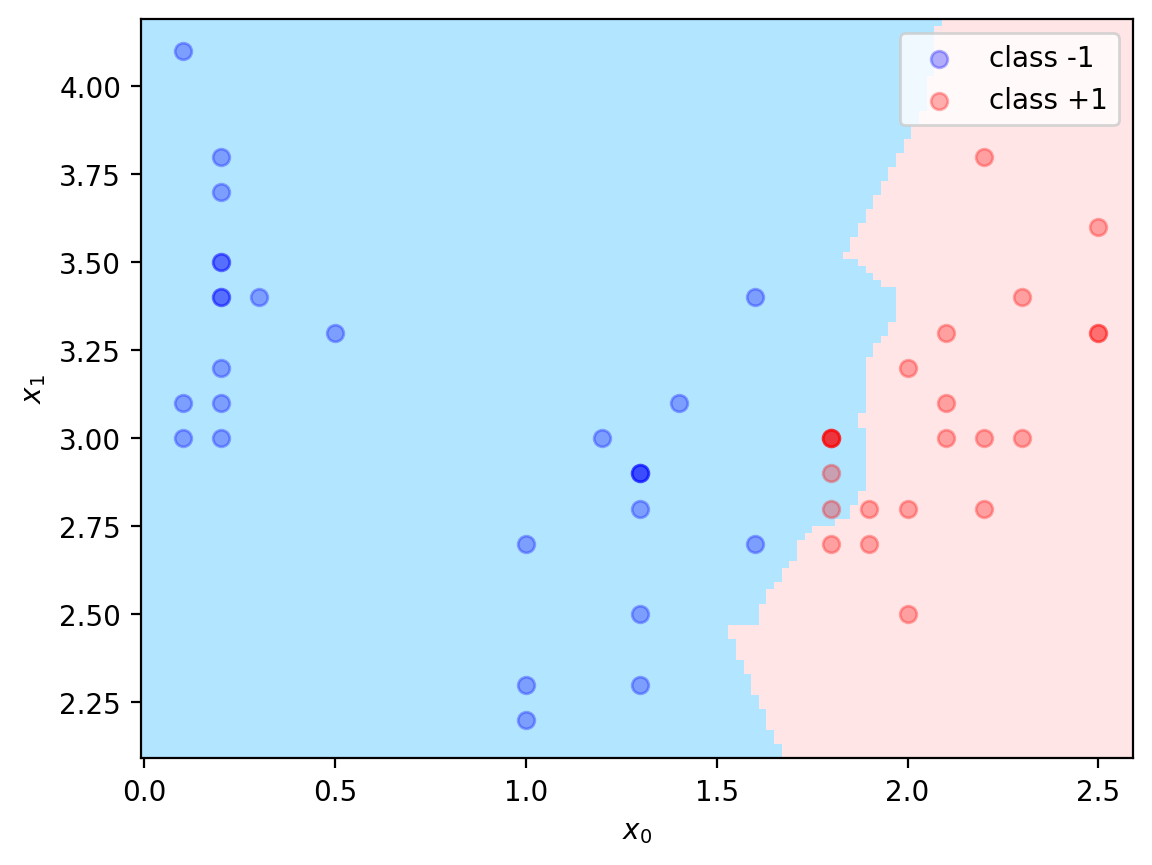

Validation error: 0.11999999731779099

k=3


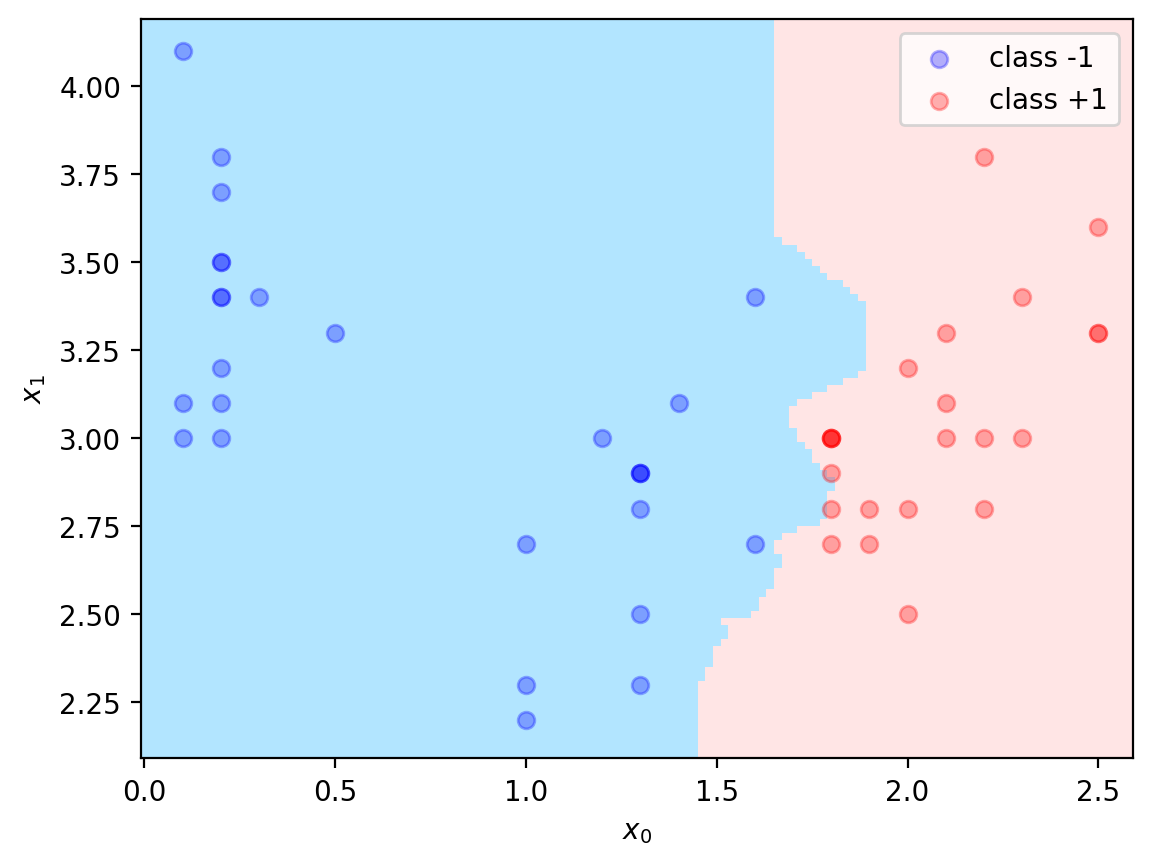

Validation error: 0.019999999552965164



In [ ]:
opt_val_error = 1.0
opt_k = None

# Try different k(s).
for k in [1,2,3]:
    # Visualize
    #   1. Validation set (as points).
    #   2. Decision boundary from training set (as background).
    print("k={}".format(k))
    # Create a k-NN classifier with training set.
    knn_classifier = partial(f_knn, X_train=X_train, Y_train=Y_train, k=k)
    # Visualization.
    vis(X_val, Y_val, knn_classifier)
    # Calculate validation error.
    val_error = calc_error(X_val, Y_val, knn_classifier)
    print("Validation error: {}\n".format(val_error))
    if val_error < opt_val_error:
        opt_val_error = val_error
        opt_k = k
        opt_knn_classifier = knn_classifier

In [ ]:
print("Best k={}".format(opt_k))
test_error = calc_error(X_test, Y_test, opt_knn_classifier)
...
print("Test error: {}".format(test_error))

Best k=3
Test error: 0.07999999821186066


<!-- END QUESTION -->

# Question 6 Decision Tree (Bonus)

In this problem, you need to implement the decision tree algorithm and apply it to the binary classification. Here we use the Ionosphere dataset $S=\{(\mathbf{x}_i, y_i)\}$ where each feature vector $\mathbf{x} \in \mathbb{R}^{34}$ and label $y \in \{-1, +1\}$. You are allowed to use the functions from `scikit-learn` in this question.

- Load the Ionosphere dataset. The dataset $S$ is split to two subsets: The training set $S_\text{training}$ and the test set $S_\text{test}$. In the code, we use `X_train`, `Y_train` for the feature vectors and labels of the training set respectively. Similar notations are also used for the test set.

- Train the decision tree classifier with the **entropy criterion**. In the decision tree, there is a hyper-parameter $D$ which controls the maximum depth. You would need to perform a grid search on the following list of $D$:
$$D \in \{1,2,3,4,5\}$$

For each $D$, you need to form a decision tree classifier with the training set $S_\text{training}$. Specifically, you need to conduct a **10-fold** cross-validation on $S_\text{training}$ and calculate the cross-validation error $\bar{e}$ (i.e. average validation error over the splits in cross-validation). We aim to obtain the best hyper-parameter $D^*$ corresponding to the **minimum cross-validation error** $\bar{e}^*$ among all $D\text{s}$.


- Use the obtained classifier corresponding to the best hyper-parameter $D^*$ to calculate the test error $e_\text{test}$ on test set $S_\text{test}$.   




In [ ]:
%config InlineBackend.figure_format = 'retina'
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn import tree
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

### Load the Ionosphere dataset

In [ ]:
# Ionosphere dataset.
X_and_Y = np.load('ionosphere.npy').astype(np.float32) # Load data from file.

np.random.seed(1)               # Set the random seed.
np.random.shuffle(X_and_Y)      # Shuffle the data.
X = X_and_Y[:, 0:-1]            # First column to second last column: Features.
Y = X_and_Y[:, -1]              # Last column: Labels.
Y[Y==0] = -1                    # Convert labels from {0, 1} to {-1, 1}.

print(X.shape)      # (351, 34)
print(Y.shape)      # (351,)
print(X_and_Y[0])
# The result should be:
# [ 1.       0.      -0.205    0.2875   0.23     0.1      0.2825   0.3175
#   0.3225   0.35     0.36285 -0.34617  0.0925   0.275   -0.095    0.21
#  -0.0875   0.235   -0.34187  0.31408 -0.48    -0.08     0.29908  0.33176
#  -0.58    -0.24     0.3219  -0.28475 -0.47     0.185   -0.27104 -0.31228
#   0.40445  0.0305   1.     ]

(351, 34)
(351,)
[ 1.       0.      -0.205    0.2875   0.23     0.1      0.2825   0.3175
  0.3225   0.35     0.36285 -0.34617  0.0925   0.275   -0.095    0.21
 -0.0875   0.235   -0.34187  0.31408 -0.48    -0.08     0.29908  0.33176
 -0.58    -0.24     0.3219  -0.28475 -0.47     0.185   -0.27104 -0.31228
  0.40445  0.0305   1.     ]


In [ ]:
# Divide the data points into training set and test set.
X_shuffled = X
Y_shuffled = Y
X_train = X_shuffled[:200]          # Shape: (200, 34)
Y_train = Y_shuffled[:200]          # Shape: (200,)
X_test = X_shuffled[200:]           # Shape: (151,4)
Y_test = Y_shuffled[200:]           # Shape: (151,)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(200, 34)
(200,)
(151, 34)
(151,)


<!-- BEGIN QUESTION -->

### Decision Tree Using Scikit-Learn

In [ ]:
# Perform grid search for best max depth.

# 1. Create a decision tree classifier.
#    Hint: You can use tree.DecisionTreeClassifier()
#          We use "entropy" as the criterion. The random state should be
#          set to 1 for consistent results. Other options are left at default.
estimator = tree.DecisionTreeClassifier(criterion='entropy')
# 2. Create a grid searcher with cross-validation.
D_list = [1, 2, 3, 4, 5]
param_grid = {'max_depth': D_list}
#    Hint: You can use GridSearchCV()
#          Please set a 10-fold cross-validation.
grid_search = GridSearchCV(estimator, param_grid, cv=10, scoring='accuracy', n_jobs=-1)
# 3. Use the grid searcher to fit the training set.
#    - This grid searcher will try every max depth in the list.
#    - For each max depth, a cross-validation is applied to the training set,
#      that is, it creates several (training subset, validation subset) pairs.
#      Note: Sometimes the validation subset is called as "test" subset, but it
#            is not the subset of real test set.
#        - For each pair, a decision tree classifier will be trained on the
#          training subset and evaluated on validation subset.
#        - The average validation scores will be kept.
#
#    Hint: You can simply use .fit() function of the grid searcher.

grid_search.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(criterion='entropy'),
             n_jobs=-1, param_grid={'max_depth': [1, 2, 3, 4, 5]},
             scoring='accuracy')

### Visualize the Results

_Points:_ 4

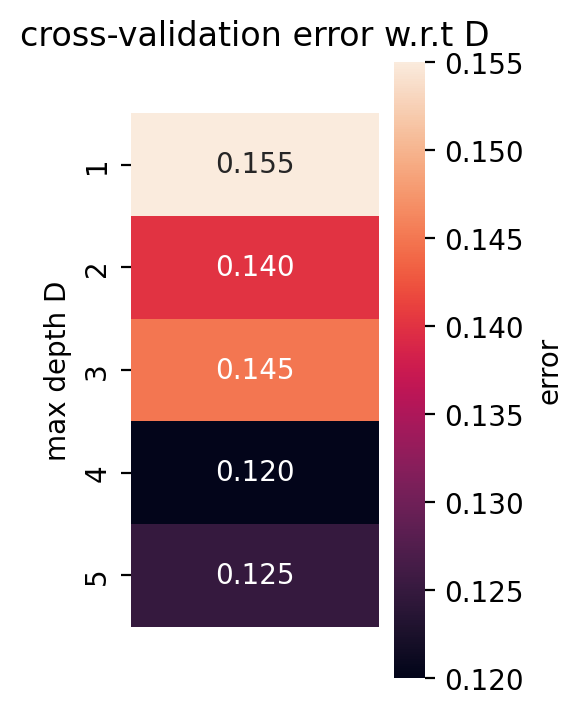

In [ ]:
# Draw heatmaps for result of grid search.
def draw_heatmap(errors, D_list, title):
    plt.figure(figsize = (2,4))
    ax = sns.heatmap(errors, annot=True, fmt='.3f', yticklabels=D_list, xticklabels=[])
    ax.collections[0].colorbar.set_label('error')
    ax.set(ylabel='max depth D')
    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom + 0.5, top - 0.5)
    plt.title(title)
    plt.show()

# Draw heatmaps of cross-validation errors (in cross-validation).
# Hint: You can use .cv_results['mean_test_score'] to obtain
#       cross-validation accuracy (that is, average validation accuracy over
#       different splits in the cross-validation). You need to convert it
#       to the error.
#       Note that you need to reshape the results to shape (?, 1), which is
#       needed by draw_heatmap().
cross_val_errors = 1 - grid_search.cv_results_['mean_test_score'].reshape(-1,1)
draw_heatmap(cross_val_errors, D_list, title='cross-validation error w.r.t D')

In [ ]:
# Show the best max depth.
# Hint: You can use the .best_params_ of the grid searcher
#       to obtain the best parameter(s).
best_max_depth = grid_search.best_params_['max_depth']
print("Best max depth D: {}".format(best_max_depth))

# Calculate the test error.
# Hint: You can use .best_estimator_.predict() to make predictions.
test_error = 1 - sum(grid_search.best_estimator_.predict(X_test) == Y_test) / len(X_test)
print("Test error: {}".format(test_error))

Best max depth D: 4
Test error: 0.1258278145695364


<!-- END QUESTION -->

# END of A6

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit.

Please make sure to see the output of the gradescope autograder. You are responsible for waiting and ensuring that the autograder is executing normally for your submission. Please create a Piazza post if you see errors in autograder execution.

In [ ]:
grader.export(pdf=False, force_save=True, run_tests=True, files=['requirements.txt', 'ionosphere.npy'])

<IPython.core.display.Javascript object>

/opt/anaconda3/envs/cogs118a/lib/python3.12/site-packages/otter/check/notebook.py:434: UserWarning: Couldn't automatically save the notebook; we recommend using File > Save & Checkpoint and then re-running this cell. The zip file returned by this call will use the last saved version of this notebook.
  warnings.warn(


Running your submission against local test cases...


Your submission received the following results when run against available test cases:

    Q1_1 results: All test cases passed!
